This notebook is used to demonstrate the usage of implicit function theorem in calculating the differentiation in an ODE system.

More information can be found in this [post](https://implicit-layers-tutorial.org/implicit_functions/).

We want to differentiate through ODE solvers whose system can be represented as:

$
\dot{y}(t) = f(t,y(t)), y(0) = y_0,
$

where $f: \mathbb{R} \times \mathbb{R}^n \rightarrow \mathbb{R}^n$ is the dynamic function and $y_0 \in \mathbb{R}^n$ is the initial value. The above equation shows that for a given $t$, the value of $y(t) \in \mathbb{R}^n$ is implicitly defined by the dynamics function $f$ and the initial value $y_0$ via the ODE system.


In [1]:
import jax
import jax.numpy as jnp
import equinox as eqx
import matplotlib.pyplot as plt

Let's take the Lorenz model for example.

In [2]:
def f(state, t, rho, sigma, beta):
    x, y, z = state
    return jnp.array([sigma * (y - x), x * (rho - z) - y, x * y - beta * z])

First, we solve it using the first-order forward Euler's method.

In [3]:
def odeint_euler(f, y0, t, *args):
    def step(state, t):
        y_prev, t_prev = state
        dt = t - t_prev
        y = y_prev + dt * f(y_prev, t_prev, *args)
        return (y, t), y
    _, ys = jax.lax.scan(step, (y0, t[0]), t[1:])
    return ys

In [4]:
ys = odeint_euler(f, jnp.array([5., 5., 5.]), jnp.linspace(0, 10., 10000),
                  28., 10., 8./3)

2025-01-17 13:09:57.365695: W external/xla/xla/service/gpu/nvptx_compiler.cc:836] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version (12.6.20). Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


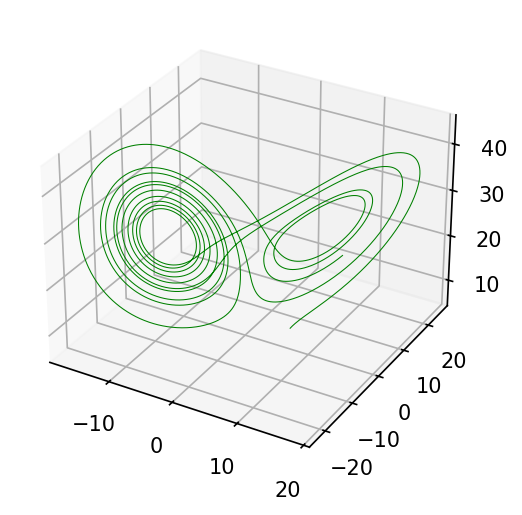

In [5]:
# Plot it
def plot_3d_path(ax, ys, color):
    x0, x1, x2 = ys.T
    ax.plot(x0, x1, x2, lw=0.5, color=color)

fig = plt.figure(figsize=(6, 4), dpi=150)
ax = fig.add_subplot(projection = '3d')
plot_3d_path(ax, ys, 'g')

Now, let's try more sophisticated solver -- a 4th order Runge-Kutta scheme.

In [6]:
def odeint_rk4(f, y0, t, *args):
    def step(state, t):
        y_prev, t_prev = state
        h = t - t_prev
        k1 = h * f(y_prev, t_prev, *args)
        k2 = h * f(y_prev + k1/2., t_prev + h/2., *args)
        k3 = h * f(y_prev + k2/2., t_prev + h/2., *args)
        k4 = h * f(y_prev + k3, t + h, *args)
        y = y_prev + 1./6 * (k1 + 2 * k2 + 2 * k3 + k4)
        return (y, t), y
    _, ys = jax.lax.scan(step, (y0, t[0]), t[1:])
    return ys

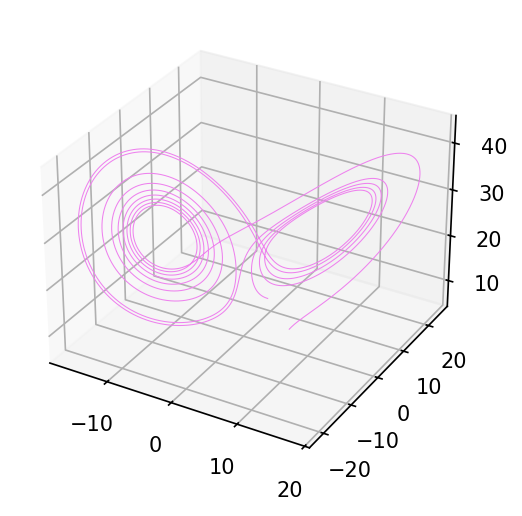

In [7]:
ys = odeint_rk4(f, jnp.array([5., 5., 5.]), jnp.linspace(0, 10., 10000),
                28., 10., 8./3)
fig = plt.figure(figsize=(6, 4), dpi=150)
ax = fig.add_subplot(projection = '3d')
plot_3d_path(ax, ys, 'violet');

We could differentiate through the operation of the numerical ODE integration algorithm. But that would quickly prove too memory-intensive for applications like Neural ODEs. Let's reformulate the system as

$
\partial_0y(t,a,b) = f(t,y(t,a,b),a), y(0,a,b) = b, t \in [0, t_n],
$

where $a \in \mathbb{R}^p$ and $b \in \mathbb{R}^n$. We would like to evaluate $\partial y(t,a,b)/\partial a$.

**Jacobian-vector products** for forward-mode means that if we nudge the parameters $a$ and $b$ to be $a+\Delta a$ and $b+\Delta b$, how does the value of $y$ at time $t$ change, to first order? That is, what is the value of $\partial_1 y(t,a,b) \Delta a + \partial_2 y(t,a,b) \Delta b$?

To that, we assume the ODE solution exists for values in a neighborhood of $a$ and differentiate both sides of the ODE equation as functions of $a$:

$
\partial_1 \partial_0 y(t,a,b) = \partial_1 f(t,y(t,a,b),a) \partial_1 y(t,a,b) + \partial_2 f(t,y(t,a,b),a).
$

The above equation can be further represented as:

$
\partial_0 \partial_1 y(t,a,b) \Delta a = \partial_1 f(t,y(t,a,b),a)\partial_1 y(t,a,b) \Delta a + \partial_2 f(t,y(t,a,b),a) \Delta a,
$

where both sides are now vectors in $\mathbb{R}^n$.

This new equation is nothing but another ODE, which can be further represented as

$\partial_0 z(t,a,b) = g(t,y(t,a,b),z(t,a,b),a),$

where $z(t,a,b) \triangleq \partial_1 y(t,a,b)\Delta a$ and $g(t,y,z,a) \triangleq \partial_1 f(t,y,a)z + \partial_2 f(t,y,a) \Delta a$.

With that, now we can define the JVP rule for our solvers.

In [8]:
odeint_rk4_jax = jax.custom_jvp(odeint_rk4, nondiff_argnums=(0,))

@odeint_rk4_jax.defjvp
def odeint_rk4_jax_jvp(f, primals, tangents):
    y0, t, *args = primals
    delta_y0, _, *delta_args = tangents
    nargs = len(args)
    
    def f_aug(aug_state, t, *args_and_delta_args):
        primal_state, tangent_state = aug_state
        args, delta_args = args_and_delta_args[:nargs], args_and_delta_args[nargs:]
        primal_dot, tangent_dot = jax.jvp(f, (primal_state, t, *args), (tangent_state, 0., *delta_args))
        return jnp.stack([primal_dot, tangent_dot])

    aug_init_state = jnp.stack([y0, delta_y0])
    aug_states = odeint_rk4(f_aug, aug_init_state, t, *args, *delta_args)
    ys, ys_dot = aug_states[:, 0, :], aug_states[:, 1, :]
    return ys, ys_dot


In [9]:
# With the self-defined JVP rule
def evolve_jax(y0, rho, sigma, beta):
    return odeint_rk4_jax(f, y0, jnp.linspace(0, 3., 10000), rho, sigma, beta)

# Without the self-defined JVP rule
def evolve(y0, rho, sigma, beta):
    return odeint_rk4(f, y0, jnp.linspace(0, 3., 10000), rho, sigma, beta)


In [47]:
# def evolve_jax2(rho, sigma, beta):
#     return odeint_rk4_jax(y0, jnp.linspace(0, 3., 10000), rho, sigma, beta, f=f)
    
# jax.jvp(evolve_jax2, 
#         (rho, sigma, beta),
#         (delta_rho, delta_sigma, delta_beta))

In [10]:
y0 = jnp.array([5., 5., 5.])
delta_y0 = jnp.array([0., 0., 0.])

rho = 28.
sigma = 10.
beta = 8./3

delta_rho = 0.
delta_sigma = 1.
delta_beta = 0.

ys, delta_ys = jax.jvp(evolve_jax,
                       (y0, rho, sigma, beta),
                       (delta_y0, delta_rho, delta_sigma, delta_beta))

ys2, delta_ys2 = jax.jvp(evolve,
                       (y0, rho, sigma, beta),
                       (delta_y0, delta_rho, delta_sigma, delta_beta))


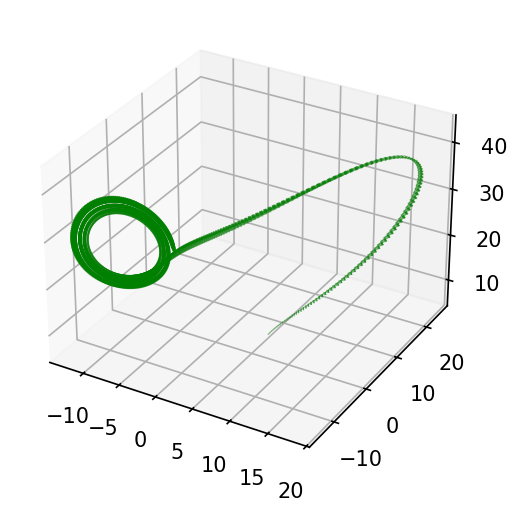

In [50]:
def plot_3d_path_with_delta(ax, ys, delta_ys, color, alpha=1.0):
    x0, x1, x2 = ys.T
    dx0, dx1, dx2 = delta_ys.T
    
    skip = 10
    ax.plot(x0, x1, x2, lw=0.5, color=color, alpha=alpha)
    ax.quiver(x0[::skip], x1[::skip], x2[::skip], dx0[::skip], dx1[::skip], dx2[::skip], color=color, alpha=alpha)
fig = plt.figure(figsize=(6, 4), dpi=150)
ax = fig.add_subplot(projection = '3d')
plot_3d_path_with_delta(ax, ys, delta_ys, 'violet', 0.1)
plot_3d_path_with_delta(ax, ys2, delta_ys2, 'green', 0.5)


Let's compare the time speedup.

In [51]:
# Without JIT, with self-defined JVP
%timeit jax.jvp(evolve_jax, (y0, rho, sigma, beta), (delta_y0, delta_rho, delta_sigma, delta_beta))


321 ms ± 12.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [52]:
# Without JIT, without self-defined JVP
%timeit jax.jvp(evolve, (y0, rho, sigma, beta), (delta_y0, delta_rho, delta_sigma, delta_beta))


445 ms ± 63.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [53]:
# With JIT, with self-defined JVP
jax.jvp(jax.jit(evolve_jax), (y0, rho, sigma, beta), (delta_y0, delta_rho, delta_sigma, delta_beta))
%timeit jax.jvp(jax.jit(evolve_jax), (y0, rho, sigma, beta), (delta_y0, delta_rho, delta_sigma, delta_beta))


178 ms ± 24.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [54]:
# With JIT, without self-defined JVP
jax.jvp(jax.jit(evolve), (y0, rho, sigma, beta), (delta_y0, delta_rho, delta_sigma, delta_beta))
%timeit jax.jvp(jax.jit(evolve), (y0, rho, sigma, beta), (delta_y0, delta_rho, delta_sigma, delta_beta))


299 ms ± 87.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
